In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("supermarket.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [4]:
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
5,6,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600
6,7,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520
8,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040
9,10,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000


In [5]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.dropna(subset=['Postal Code'], inplace=True)

In [8]:
df['Postal Code'] = df['Postal Code'].astype(int).astype(str)

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9789 non-null   int64         
 1   Order ID       9789 non-null   object        
 2   Order Date     9789 non-null   datetime64[ns]
 3   Ship Date      9789 non-null   datetime64[ns]
 4   Ship Mode      9789 non-null   object        
 5   Customer ID    9789 non-null   object        
 6   Customer Name  9789 non-null   object        
 7   Segment        9789 non-null   object        
 8   Country        9789 non-null   object        
 9   City           9789 non-null   object        
 10  State          9789 non-null   object        
 11  Postal Code    9789 non-null   object        
 12  Region         9789 non-null   object        
 13  Product ID     9789 non-null   object        
 14  Category       9789 non-null   object        
 15  Sub-Category   9789 non-nu

In [11]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

In [12]:
IQR = Q3 - Q1

In [13]:
upper_bound = Q3 + (1.5 * IQR)
lower_bound = Q1 - (1.5 * IQR)

In [14]:
df['Sales'].max()

22638.48

In [17]:
outliers = df[(df['Sales'] > upper_bound) | (df['Sales'] < lower_bound)]
print(f"\nTotal number of outliers found: {len(outliers)}")
print(f"This is { (len(outliers) / len(df) * 100):.2f}% of your total transactions.")


Total number of outliers found: 1141
This is 11.66% of your total transactions.


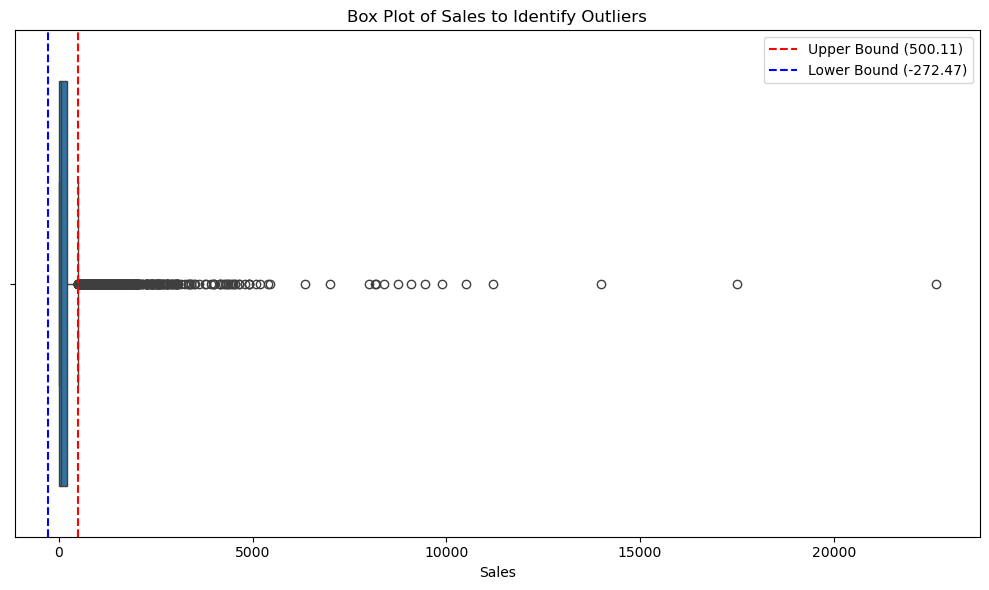

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Sales'])
plt.title('Box Plot of Sales to Identify Outliers')
plt.xlabel('Sales')
plt.axvline(x=upper_bound, color='r', linestyle='--', label=f'Upper Bound ({upper_bound:.2f})')
plt.axvline(x=lower_bound, color='b', linestyle='--', label=f'Lower Bound ({lower_bound:.2f})')
plt.legend()
plt.tight_layout()

In [19]:
df_typical = df[df['Sales'] <= upper_bound]

In [20]:
print(f"\nAnalyzing {len(df_typical)} 'Typical' customer transactions...")


Analyzing 8648 'Typical' customer transactions...


In [24]:
top_10_typical=df_typical['Sub-Category'].value_counts().head(10)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10772\3617474316.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


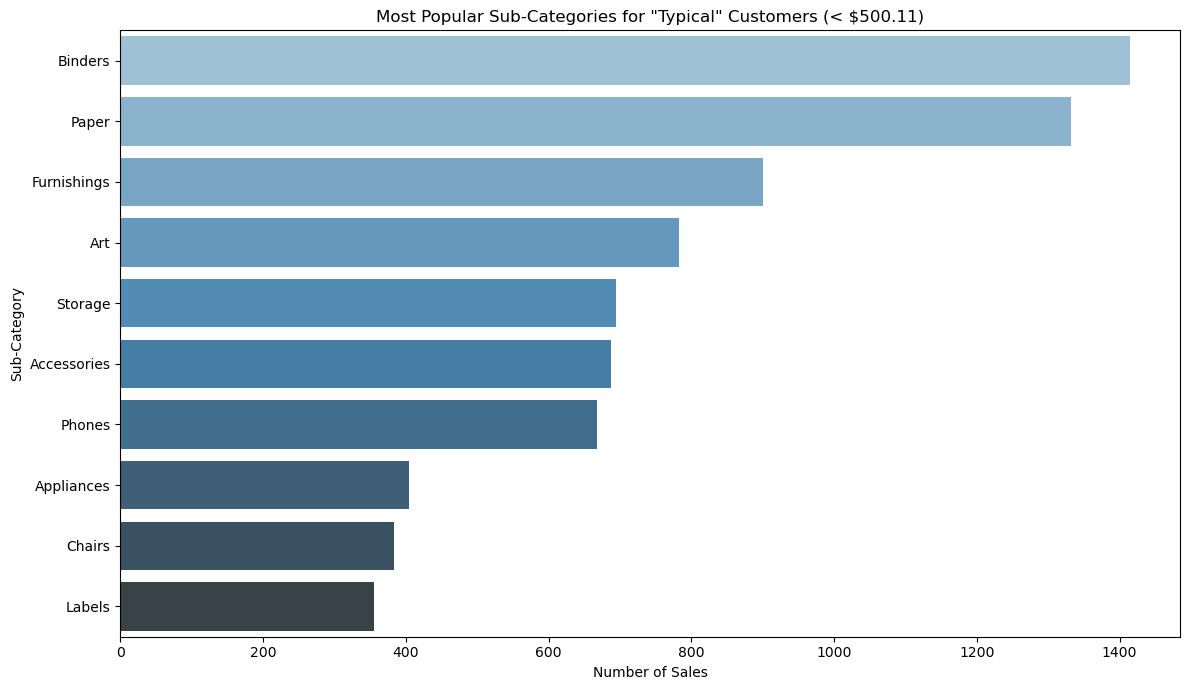

In [25]:
# 5. Create a bar chart
plt.figure(figsize=(12, 7))
sns.barplot(
    x=top_10_typical.values, 
    y=top_10_typical.index, 
    palette="Blues_d"
)
plt.title('Most Popular Sub-Categories for "Typical" Customers (< $500.11)')
plt.xlabel('Number of Sales')
plt.ylabel('Sub-Category')
plt.tight_layout()

In [27]:
df_high_value = df[df['Sales'] > upper_bound]

In [28]:
print(f"\nAnalyzing {len(df_high_value)} 'High-Value' customer transactions...")


Analyzing 1141 'High-Value' customer transactions...


In [31]:
top_10_high_value=df_high_value['Sub-Category'].value_counts().head(10)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10772\1960881569.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


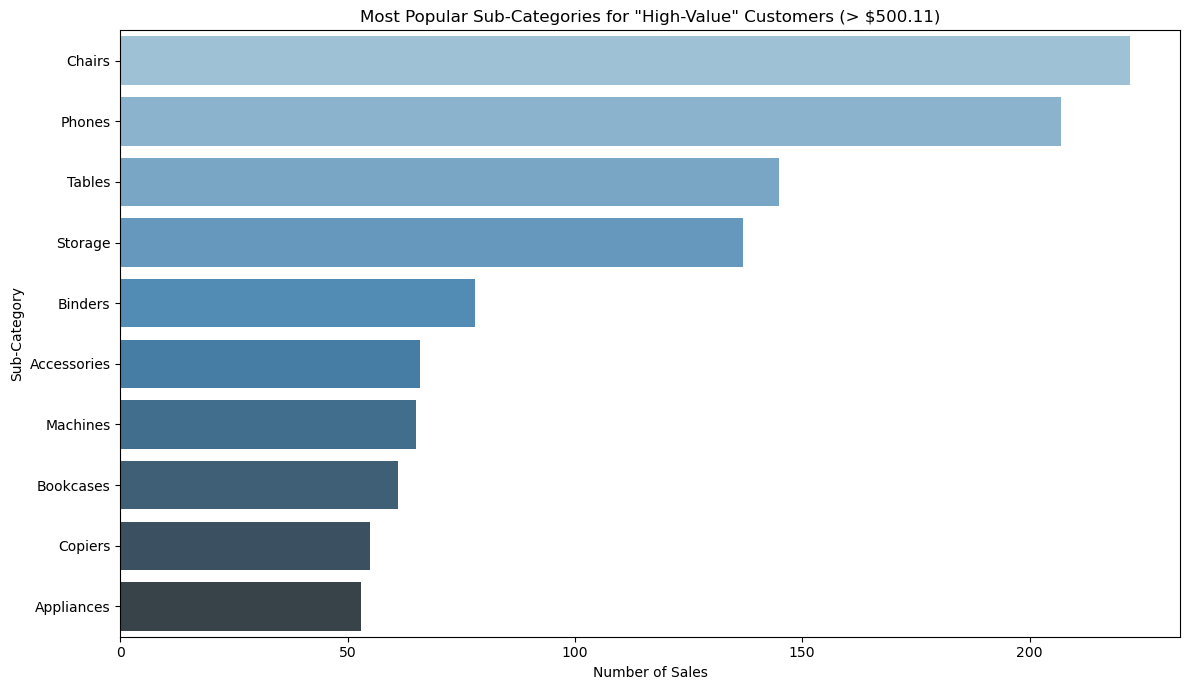

In [32]:
plt.figure(figsize=(12, 7))
sns.barplot(
    x=top_10_high_value.values, 
    y=top_10_high_value.index, 
    palette="Blues_d"  # Changed the color palette
)
plt.title('Most Popular Sub-Categories for "High-Value" Customers (> $500.11)')
plt.xlabel('Number of Sales')
plt.ylabel('Sub-Category')
plt.tight_layout()

In [63]:
typical_monthly_sales = df_typical.set_index('Order Date')['Sales'].resample('ME').sum()
high_value_monthly_sales = df_high_value.set_index('Order Date')['Sales'].resample('ME').sum()

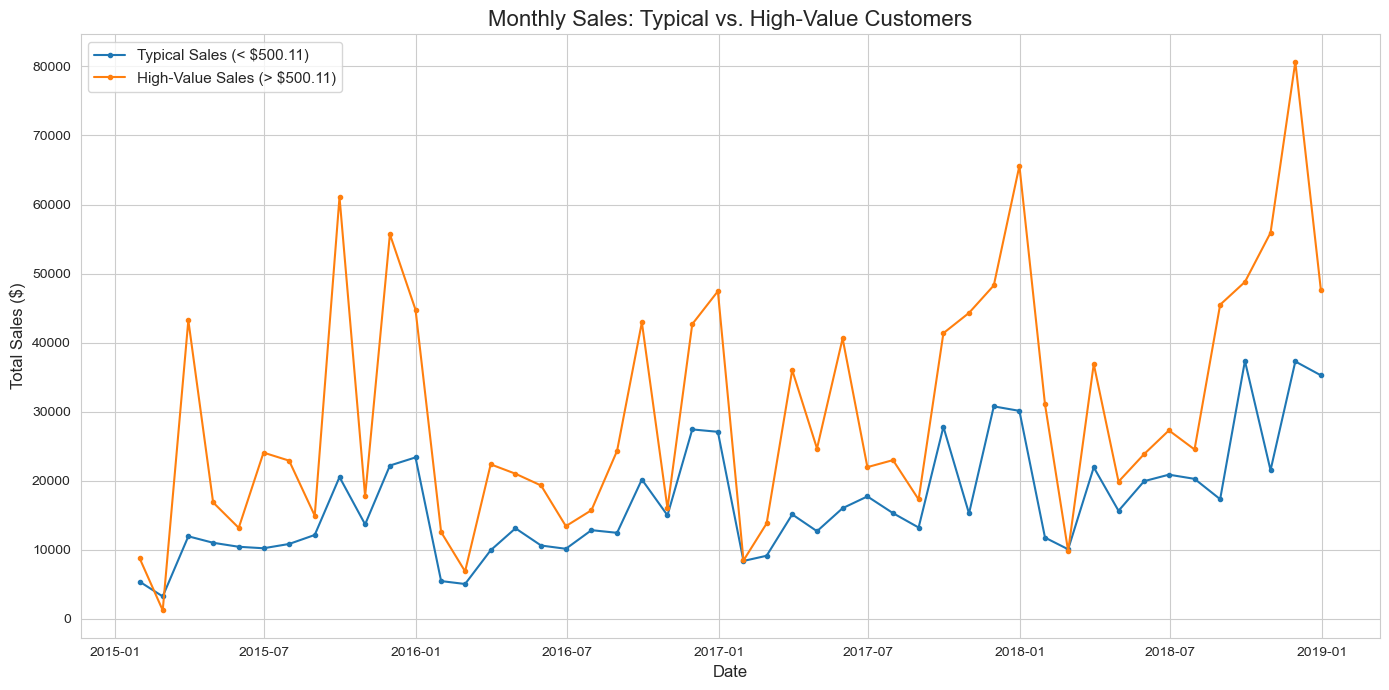

In [64]:
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Plot both time series
plt.plot(typical_monthly_sales.index, typical_monthly_sales.values, label='Typical Sales (< $500.11)', marker='.', linestyle='-')
plt.plot(high_value_monthly_sales.index, high_value_monthly_sales.values, label='High-Value Sales (> $500.11)', marker='.', linestyle='-')

# Make the plot beautiful
plt.title('Monthly Sales: Typical vs. High-Value Customers', fontsize=16)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True)
plt.tight_layout()

Generating histogram for 'Typical' Sales...


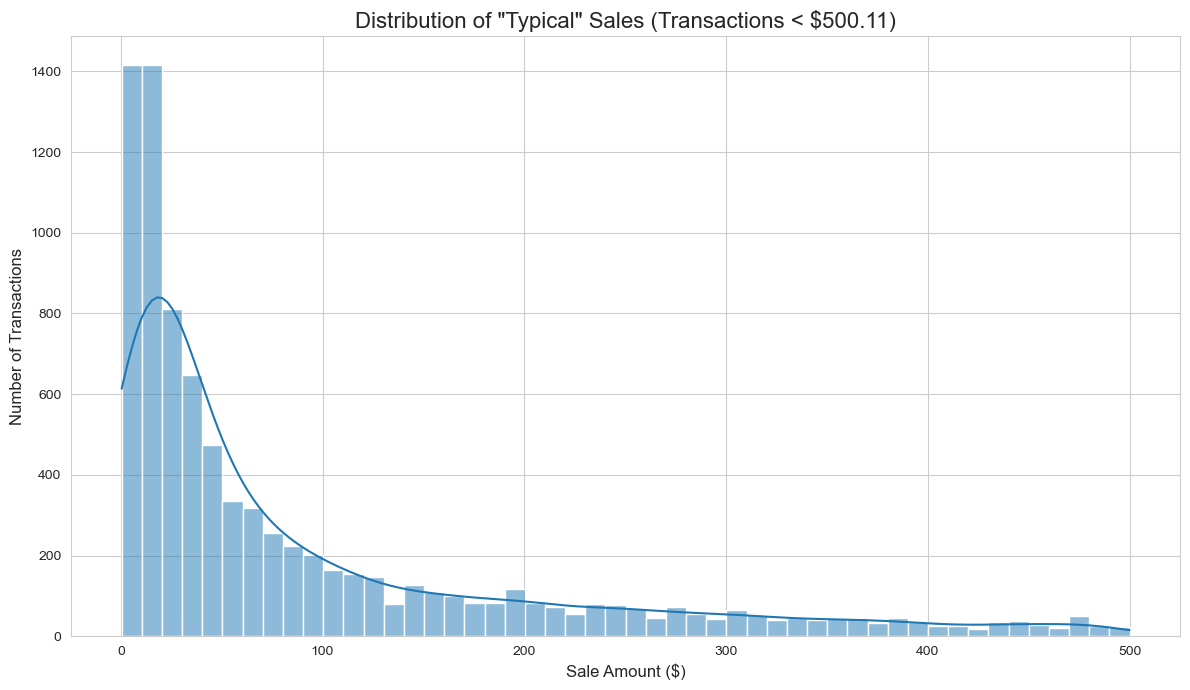

In [65]:
print("Generating histogram for 'Typical' Sales...")
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Plot the histogram
# 'bins=50' is a good starting point to see the detail
sns.histplot(df_typical['Sales'], bins=50, kde=True) # kde=True adds a smooth line

plt.title('Distribution of "Typical" Sales (Transactions < $500.11)', fontsize=16)
plt.xlabel('Sale Amount ($)', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.tight_layout()

In [67]:
segment_sales = df.groupby('Segment')['Sales'].agg(['sum', 'mean']).reset_index()
segment_sales = segment_sales.sort_values(by='sum', ascending=False)

print("\nTotal and Average Sales by Segment:")
print(segment_sales)


Total and Average Sales by Segment:
       Segment           sum        mean
0     Consumer  1.146708e+06  225.021223
1    Corporate  6.822118e+05  231.415141
2  Home Office  4.236874e+05  242.800818


In [69]:
# Group high-value sales by segment
high_value_segment_sales = df_high_value.groupby('Segment')['Sales'].agg(['sum', 'count']).reset_index()
high_value_segment_sales = high_value_segment_sales.sort_values(by='sum', ascending=False)
print("\n'High-Value' (>$500.11) Sales by Segment:")
print(high_value_segment_sales)


'High-Value' (>$500.11) Sales by Segment:
       Segment          sum  count
0     Consumer  715641.2912    556
1    Corporate  446608.1250    370
2  Home Office  284504.1567    215



Total Sales by Segment (as a Series):
Segment
Consumer       1.146708e+06
Corporate      6.822118e+05
Home Office    4.236874e+05
Name: Sales, dtype: float64

Generating pie chart for Total Sales by Segment...


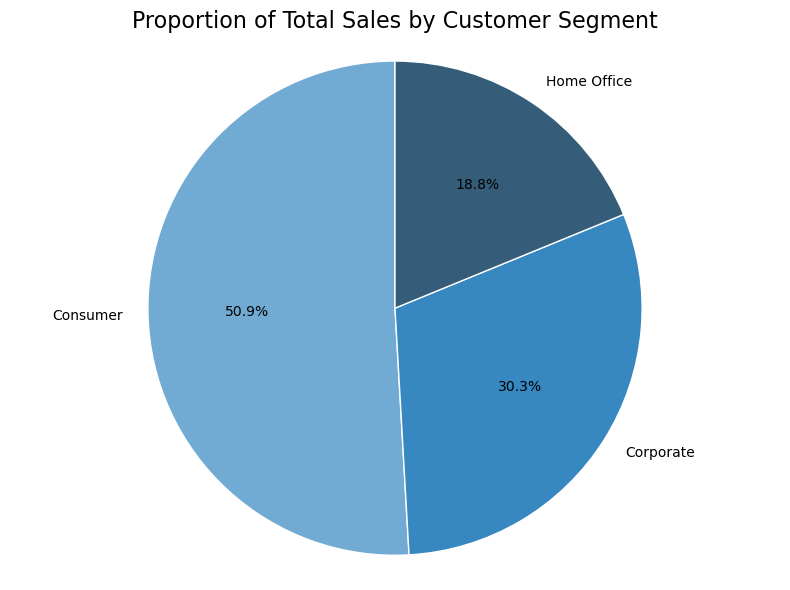

In [33]:
segment_sales_series = df.groupby('Segment')['Sales'].sum()

print("\nTotal Sales by Segment (as a Series):")
print(segment_sales_series)


# --- 3. VISUALIZATION: Pie Chart (NEW METHOD) ---
print("\nGenerating pie chart for Total Sales by Segment...")
plt.figure(figsize=(8, 6))

# Define colors
colors = sns.color_palette('Blues_d', n_colors=len(segment_sales_series))

# Create the pie chart
# We pass the values and index from the Series directly
plt.pie(
    segment_sales_series.values,   # The sales numbers
    labels=segment_sales_series.index,   # The 'Consumer', 'Corporate', 'Home Office' labels
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white'}
)

plt.title('Proportion of Total Sales by Customer Segment', fontsize=16)
plt.axis('equal')  # Ensures the pie chart is a perfect circle
plt.tight_layout()


Generating pie chart for 'Region'...


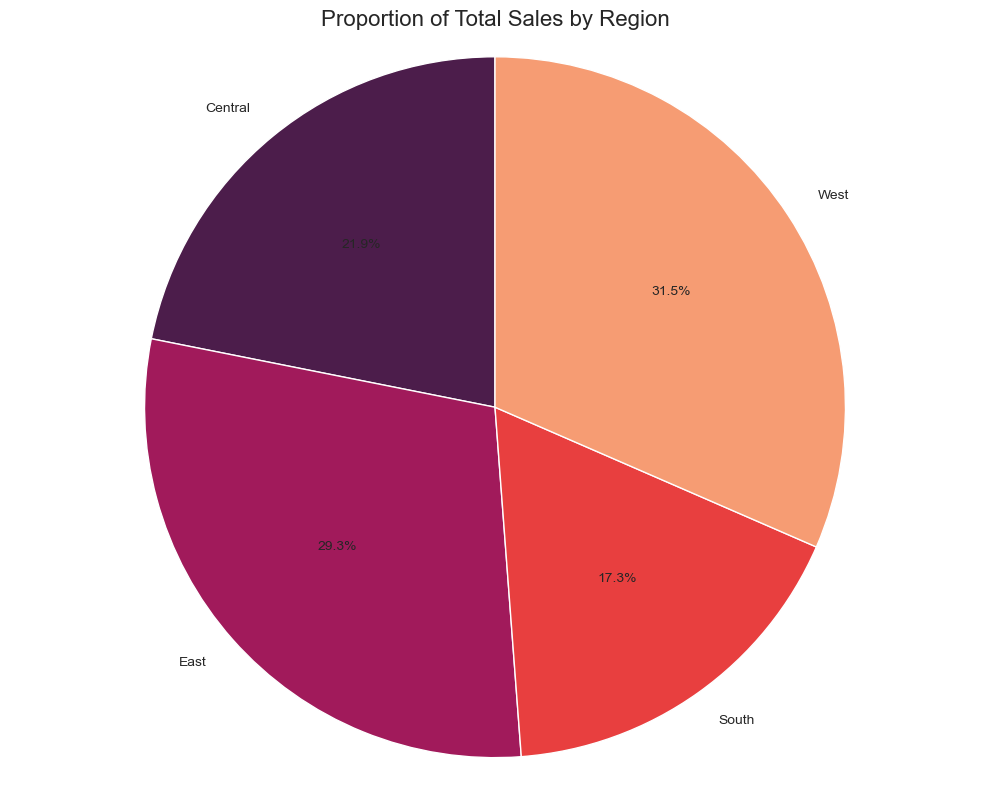

In [74]:
print("\nGenerating pie chart for 'Region'...")
region_sales = df.groupby('Region')['Sales'].sum()
plt.figure(figsize=(10, 8))
colors = sns.color_palette('rocket', n_colors=len(region_sales))
plt.pie(
    region_sales.values,
    labels=region_sales.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white'}
)
plt.title('Proportion of Total Sales by Region', fontsize=16)
plt.axis('equal')
plt.tight_layout()


Generating Top 10 bar chart for 'State'...


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21700\3643194362.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


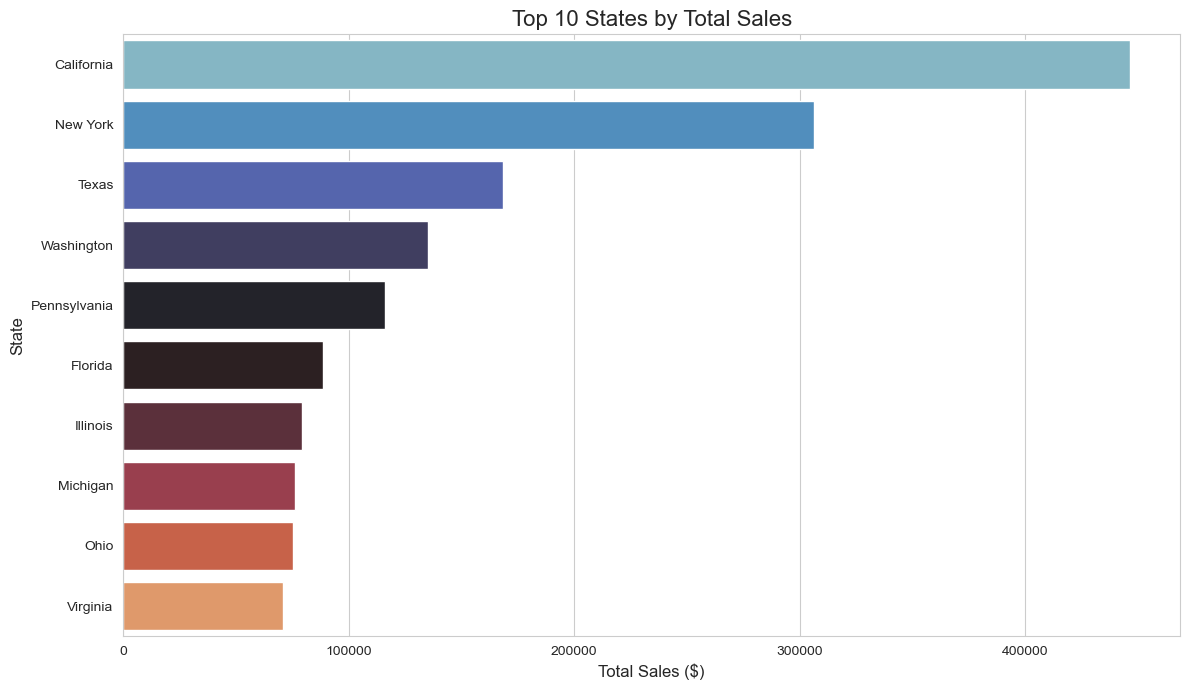

In [75]:
print("\nGenerating Top 10 bar chart for 'State'...")
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
sns.barplot(
    x=state_sales.values,
    y=state_sales.index,
    palette='icefire'
)
plt.title('Top 10 States by Total Sales', fontsize=16)
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.tight_layout()


Generating Top 10 bar chart for 'City'...


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21700\304688305.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


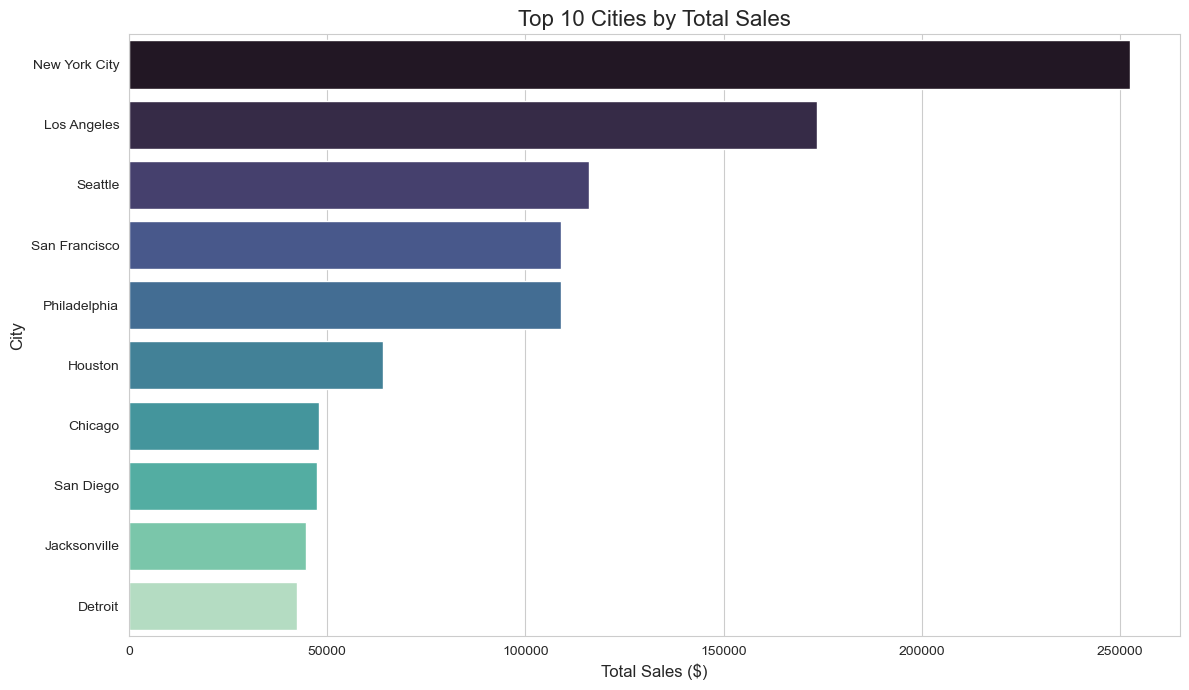

In [76]:
print("\nGenerating Top 10 bar chart for 'City'...")
city_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
sns.barplot(
    x=city_sales.values,
    y=city_sales.index,
    palette='mako'
)
plt.title('Top 10 Cities by Total Sales', fontsize=16)
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.tight_layout()


Generating Heat Map for Sales by Month/Year...


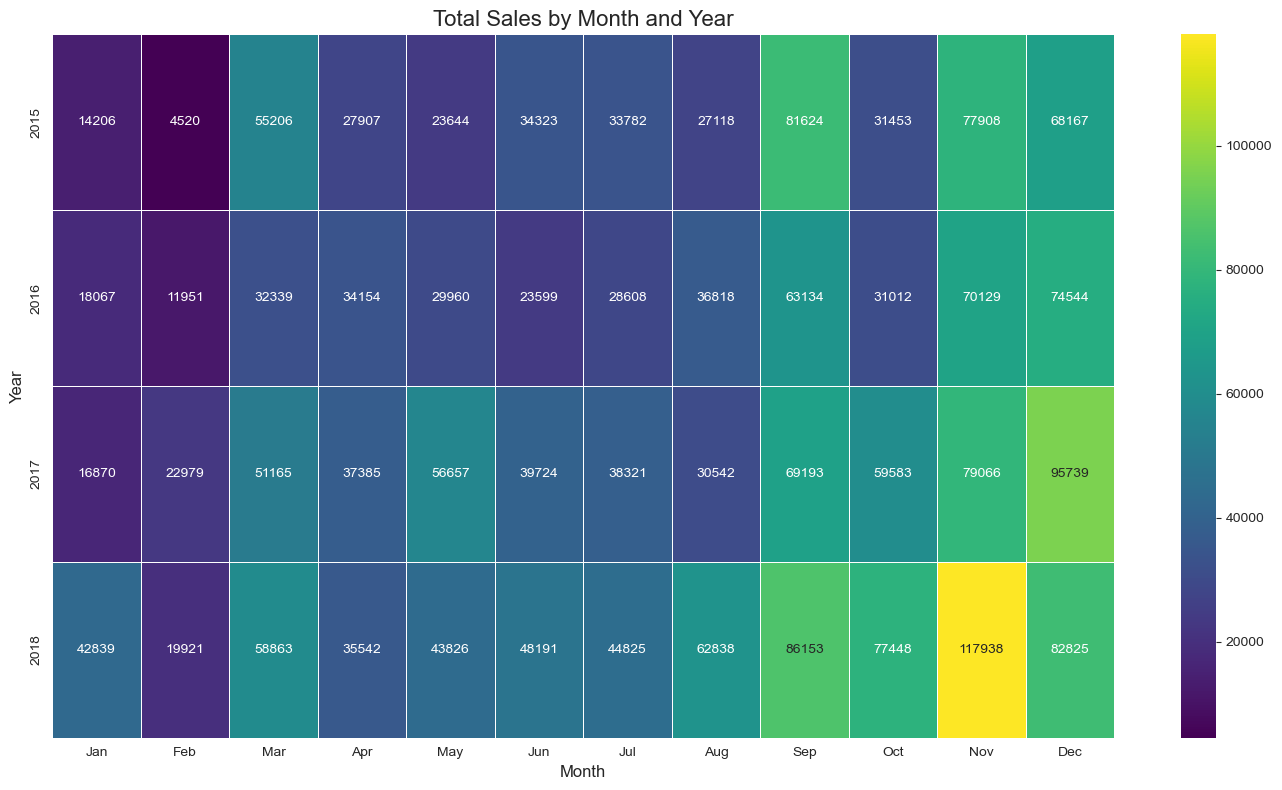

In [78]:
print("\nGenerating Heat Map for Sales by Month/Year...")
# Create 'Year' and 'Month' columns
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

# Create a pivot table to 'grid' the data
heatmap_data = df.pivot_table(
    values='Sales', 
    index='Year', 
    columns='Month', 
    aggfunc='sum'
)
# Re-order columns to be Jan, Feb, Mar...
heatmap_data = heatmap_data.reindex(columns=range(1,13))

plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data, 
    annot=True,     # Show the numbers in the squares
    fmt='.0f',      # Format as whole numbers
    cmap='viridis', # Color palette
    linewidths=.5
)
plt.title('Total Sales by Month and Year', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Year', fontsize=12)
# Set month labels
plt.xticks(ticks=np.arange(12) + 0.5, labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.tight_layout()

Generating heatmap...


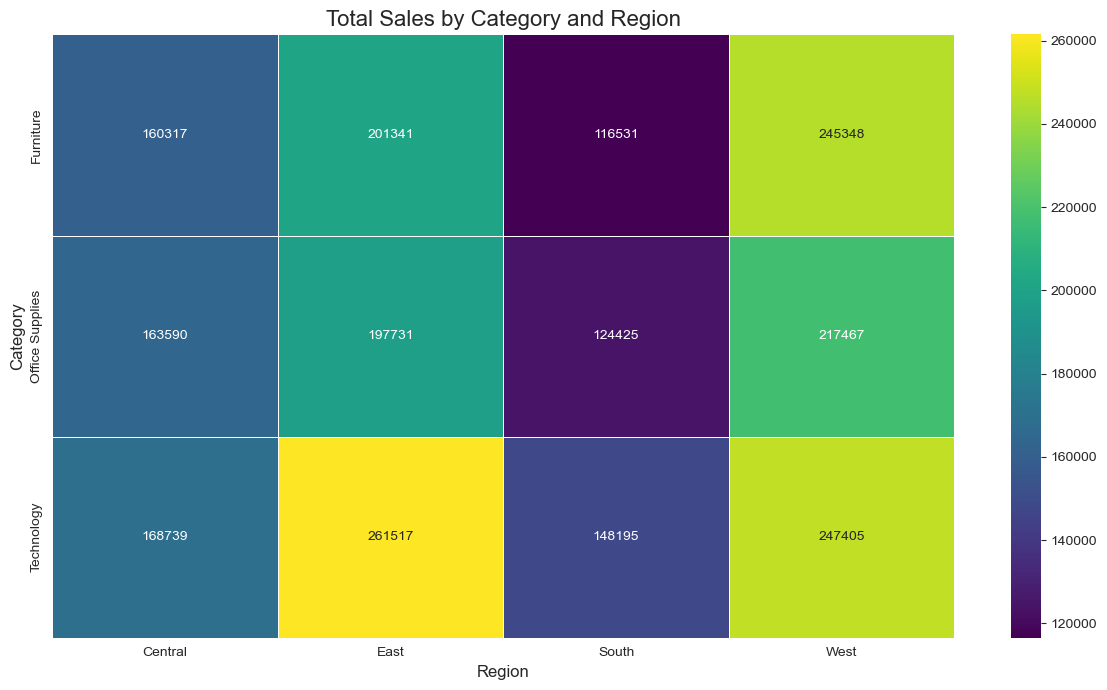

In [82]:
heatmap_data = df.pivot_table(
    values='Sales', 
    index='Category', 
    columns='Region', 
    aggfunc='sum'
)

# --- 3. CREATE THE HEATMAP ---
print("Generating heatmap...")
plt.figure(figsize=(12, 7))
sns.heatmap(
    heatmap_data, 
    annot=True,     # Show the numbers in the squares
    fmt='.0f',      # Format as whole numbers (no decimals)
    cmap='viridis', # Color palette
    linewidths=.5    # Add thin lines between cells
)
plt.title('Total Sales by Category and Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()


Calculating counts for 'Category'...

Transaction Counts by Category:
Category
Office Supplies    5903
Furniture          2076
Technology         1810
Name: count, dtype: int64
Generating vertical bar chart...


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21700\827877771.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


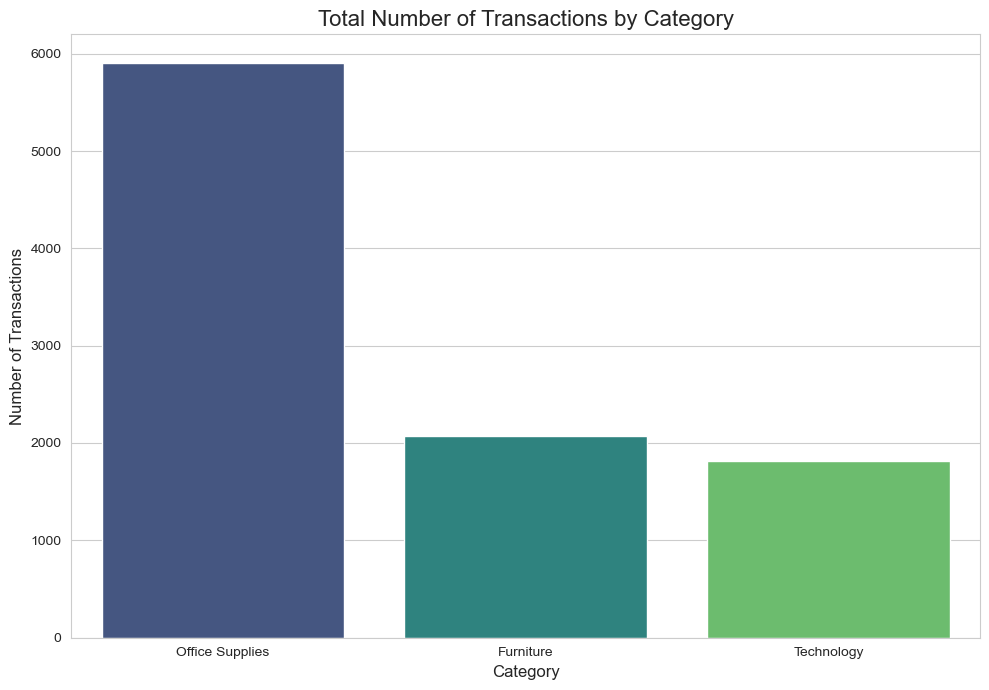

In [83]:
# --- 2. GET CATEGORY COUNTS ---
print("\nCalculating counts for 'Category'...")
category_counts = df['Category'].value_counts()

print("\nTransaction Counts by Category:")
print(category_counts)

# --- 3. CREATE THE VERTICAL BAR CHART ---
print("Generating vertical bar chart...")
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")

# For a vertical chart, the category names are on the x-axis
# and the counts are on the y-axis.
sns.barplot(
    x=category_counts.index,   # X-axis: 'Office Supplies', 'Technology', etc.
    y=category_counts.values,  # Y-axis: The actual numbers
    palette='viridis'
)

plt.title('Total Number of Transactions by Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.tight_layout()


Analyzing Top 10 Cities: ['New York City', 'Los Angeles', 'Seattle', 'San Francisco', 'Philadelphia', 'Houston', 'Chicago', 'San Diego', 'Jacksonville', 'Detroit']

Transaction Counts for Top 10 Cities:
Category       Furniture  Office Supplies  Technology
City                                                 
New York City        187              535         169
Los Angeles          151              432         145
Seattle               96              248          82
San Francisco         99              317          84
Philadelphia         111              308         113
Houston               80              229          65
Chicago               68              183          57
San Diego             46               88          36
Jacksonville          24               73          28
Detroit               28               65          22

Generating stacked bar chart...


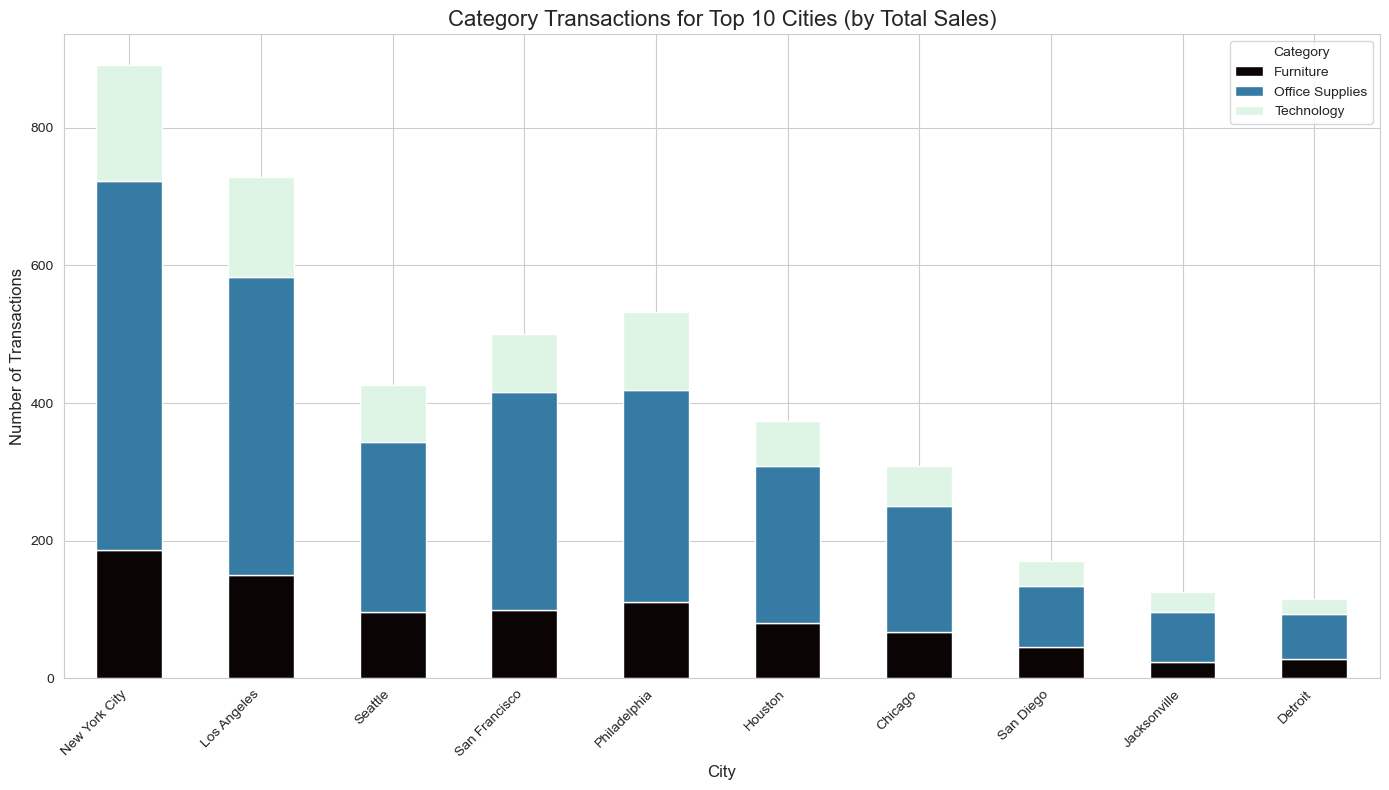

In [34]:
# --- 2. FIND TOP 10 CITIES BY SALES ---
# We do this to analyze only the most important cities
top_10_cities = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10).index
print(f"\nAnalyzing Top 10 Cities: {list(top_10_cities)}")

# Filter the DataFrame to *only* these 10 cities
df_top10 = df[df['City'].isin(top_10_cities)]

# --- 3. CREATE THE CROSSTAB DATA ---
# This creates a table with City as rows, Category as columns,
# and the count of transactions in the cells
city_category_counts = pd.crosstab(
    df_top10['City'],
    df_top10['Category']
)

# Re-order the table to match the top 10 sales order
city_category_counts = city_category_counts.reindex(top_10_cities)

print("\nTransaction Counts for Top 10 Cities:")
print(city_category_counts)

# --- 4. CREATE THE STACKED BAR CHART ---
print("\nGenerating stacked bar chart...")
sns.set_style("whitegrid")
# Pandas .plot() is the easiest way to make a stacked bar chart
city_category_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 8),
    cmap='mako'  # A nice color map
)

plt.title('Category Transactions for Top 10 Cities (by Total Sales)', fontsize=16)
plt.xlabel('City', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate labels so they don't overlap
plt.legend(title='Category', loc='upper right')
plt.tight_layout()